In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

HEART DISEASE PREDICTION - TASK 3

✅ Dataset: 1000 patients, 7 features
✅ Target: 0 = No Disease, 1 = Disease

First 5 rows:
   age  blood_pressure  cholesterol  max_heart_rate  chest_pain  blood_sugar  \
0   67             190          202             100           1            1   
1   57             113          241             109           1            0   
2   43             105          279             178           0            0   
3   71             140          531             181           3            0   
4   36              94          228              95           3            0   

   exercise_angina  target  
0                0       0  
1                1       1  
2                0       0  
3                0       1  
4                0       0  

Target Distribution:
target
0    528
1    472
Name: count, dtype: int64
Disease: 47.2%

MODEL RESULTS

✅ Accuracy: 0.8150
✅ ROC-AUC Score: 0.8981

Confusion Matrix:
   Predicted NO: 93  Predicted YES: 20
   Predicted NO

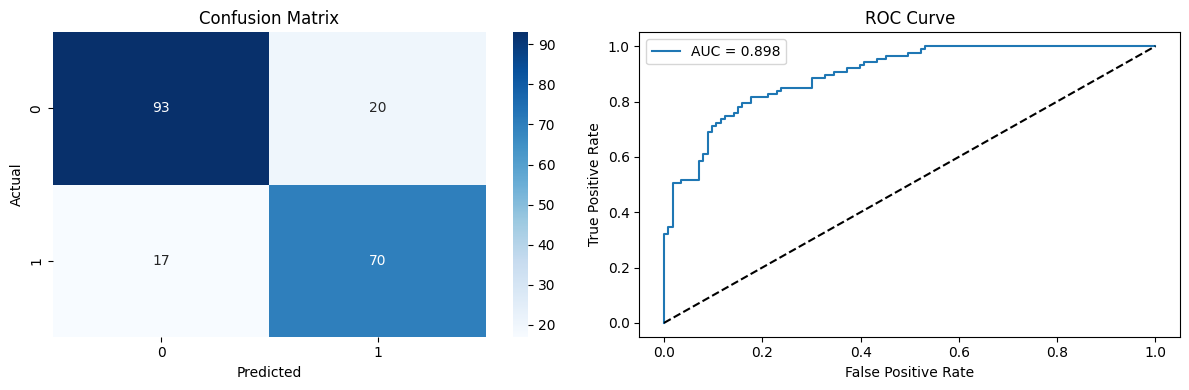


TASK 3 COMPLETED SUCCESSFULLY!


In [2]:
# Task 3: Heart Disease Prediction
# DevelopersHub Corporation - AI/ML Internship
# COMPLETE CODE - Copy paste and run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

print("="*50)
print("HEART DISEASE PREDICTION - TASK 3")
print("="*50)

# Create sample dataset (no download needed)
np.random.seed(42)
n = 1000

data = {
    'age': np.random.randint(29, 77, n),
    'blood_pressure': np.random.randint(94, 200, n),
    'cholesterol': np.random.randint(126, 564, n),
    'max_heart_rate': np.random.randint(71, 202, n),
    'chest_pain': np.random.randint(0, 4, n),
    'blood_sugar': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'exercise_angina': np.random.choice([0, 1], n, p=[0.68, 0.32]),
}

df = pd.DataFrame(data)

# Create target (heart disease: 1 = yes, 0 = no)
df['target'] = (
    (df['age'] > 55) * 0.3 +
    (df['cholesterol'] > 240) * 0.3 +
    (df['max_heart_rate'] < 140) * 0.2 +
    (df['chest_pain'] >= 2) * 0.2
)
df['target'] = (df['target'] > 0.5).astype(int)

print(f"\n✅ Dataset: {len(df)} patients, {len(df.columns)-1} features")
print(f"✅ Target: 0 = No Disease, 1 = Disease")

print("\nFirst 5 rows:")
print(df.head())

print("\nTarget Distribution:")
print(df['target'].value_counts())
print(f"Disease: {df['target'].mean()*100:.1f}%")

# Split data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Results
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*50)
print("MODEL RESULTS")
print("="*50)
print(f"\n✅ Accuracy: {accuracy:.4f}")
print(f"✅ ROC-AUC Score: {auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"   Predicted NO: {cm[0,0]}  Predicted YES: {cm[0,1]}")
print(f"   Predicted NO: {cm[1,0]}  Predicted YES: {cm[1,1]}")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("="*50)